In [20]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240703

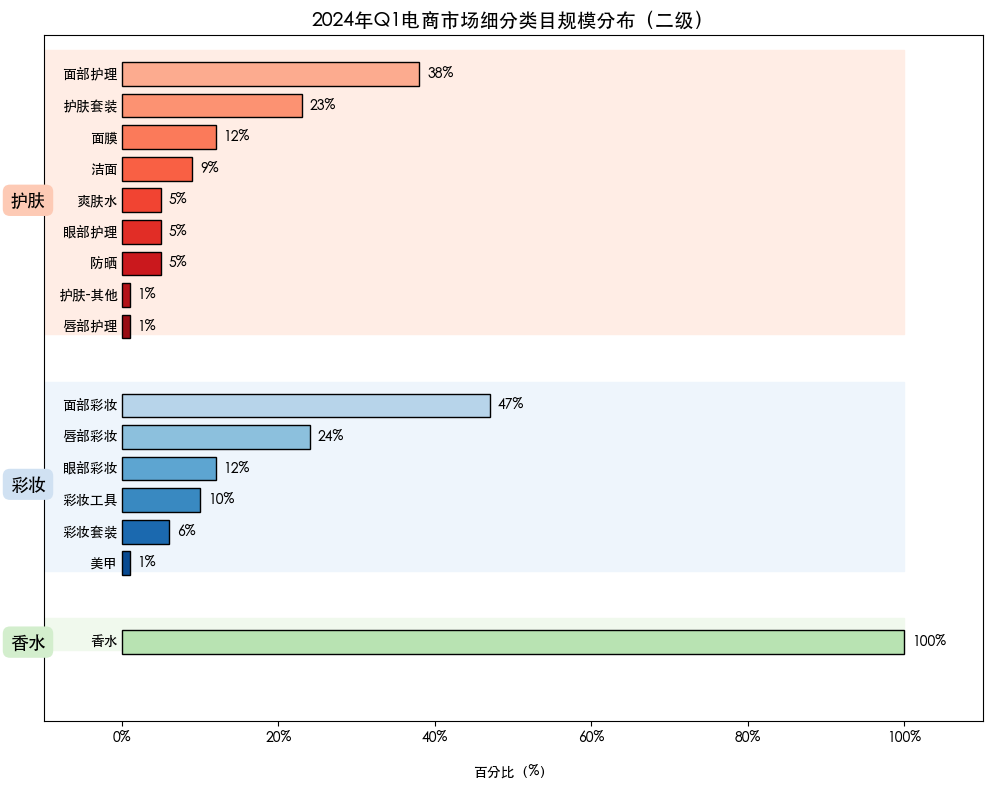

In [54]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 数据
categories = {
    '护肤': {
        'labels': ['面部护理', '护肤套装', '面膜', '洁面', '爽肤水', '眼部护理', '防晒', '护肤-其他', '唇部护理'],
        'values': [38, 23, 12, 9, 5, 5, 5, 1, 1],
        'color': 'Reds'
    },
    '彩妆': {
        'labels': ['面部彩妆', '唇部彩妆', '眼部彩妆', '彩妆工具', '彩妆套装', '美甲'],
        'values': [47, 24, 12, 10, 6, 1],
        'color': 'Blues'
    },
    '香水': {
        'labels': ['香水'],
        'values': [100],
        'color': 'Greens'
    }
}

# 初始化图形
fig, ax = plt.subplots(figsize=(10, 8))
y_base = 0
bar_height = 0.6
group_gap = 1.2
label_padding = 0.5

# 绘图主循环
for group_index, (group, content) in enumerate(categories.items()):
    labels = content['labels']
    values = content['values']
    cmap = plt.get_cmap(content['color'])
    num_items = len(values)

    # 色阶
    colors = [cmap(0.3 + 0.6 * i / max(len(values)-1, 1)) for i in range(len(values))]

    # 背景区块
    ax.add_patch(
        patches.Rectangle(
            (-10, y_base - bar_height/2 - 0.3),
            110, num_items * (bar_height + 0.2),
            color=cmap(0.05), zorder=0
        )
    )

    # 左侧组名标签
    ax.text(-12, y_base + (num_items - 1) * (bar_height + 0.2)/2,
            f'{group}', va='center', ha='center',
            fontsize=13, weight='bold', bbox=dict(facecolor=cmap(0.2), boxstyle='round,pad=0.4', edgecolor='none'))

    for i, (label, value) in enumerate(zip(labels, values)):
        y = y_base + i * (bar_height + 0.2)
        ax.barh(y, value, height=bar_height, color=colors[i], edgecolor='black')
        ax.text(value + 1, y, f'{value}%', va='center', ha='left', fontsize=10)
        ax.text(-0.5, y, label, va='center', ha='right', fontsize=10)

    y_base += num_items * (bar_height + 0.2) + group_gap

# 格式设置
ax.set_xlim(-10, 110)
ax.set_ylim(-1, y_base)
ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels([f'{x}%' for x in range(0, 101, 20)])
ax.set_yticks([])
ax.set_xlabel('百分比（%）', labelpad=15)
ax.set_title('2024年Q1电商市场细分类目规模分布（二级）', fontsize=14, weight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


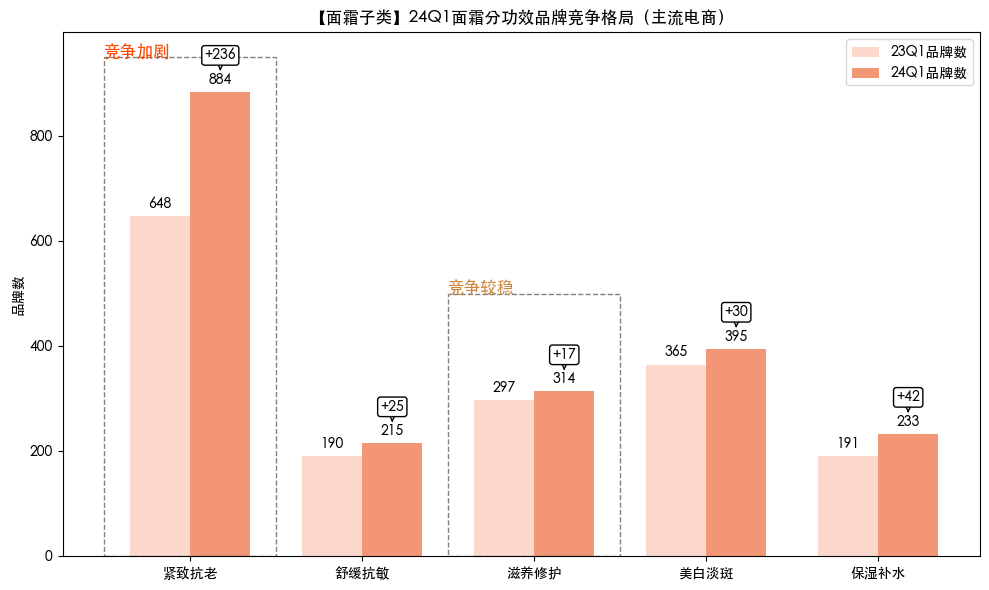

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches
from matplotlib import font_manager as fm

# 中文字体支持（适配用户的Jupyter环境设定）
chinese_fonts = [
    "SimHei", "Heiti TC", "WenQuanYi Micro Hei", "Microsoft YaHei", "Arial Unicode MS"
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams['axes.unicode_minus'] = False

# 数据
categories = ['紧致抗老', '舒缓抗敏', '滋养修护', '美白淡斑', '保湿补水']
q1_2023 = [648, 190, 297, 365, 191]
q1_2024 = [884, 215, 314, 395, 233]
growth = [q1_2024[i] - q1_2023[i] for i in range(len(q1_2023))]

x = np.arange(len(categories))
width = 0.35

# 色彩设置
color_2023 = '#fcd7cc'
color_2024 = '#f29676'

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, q1_2023, width, label='23Q1品牌数', color=color_2023)
bars2 = ax.bar(x + width/2, q1_2024, width, label='24Q1品牌数', color=color_2024)

# 数值标签
for i in range(len(x)):
    ax.text(x[i] - width/2, q1_2023[i] + 10, str(q1_2023[i]), ha='center', va='bottom', fontsize=10)
    ax.text(x[i] + width/2, q1_2024[i] + 10, str(q1_2024[i]), ha='center', va='bottom', fontsize=10)
    ax.annotate(f'+{growth[i]}',
                xy=(x[i] + width/2, q1_2024[i] + 40),
                xytext=(x[i] + width/2, q1_2024[i] + 60),
                ha='center',
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', lw=1))

# 分组边框区域
ax.add_patch(patches.Rectangle((-0.5, 0), 1.0, 950, fill=False, edgecolor='gray', linestyle='--', linewidth=1))
ax.text(-0.5, 950, '竞争加剧', color='orangered', fontsize=12)

ax.add_patch(patches.Rectangle((1.5, 0), 1.0, 500, fill=False, edgecolor='gray', linestyle='--', linewidth=1))
ax.text(1.5, 500, '竞争较稳', color='peru', fontsize=12)

# 其余设置
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('品牌数')
ax.set_title('【面霜子类】24Q1面霜分功效品牌竞争格局（主流电商）')
ax.legend()

plt.tight_layout()
plt.show()


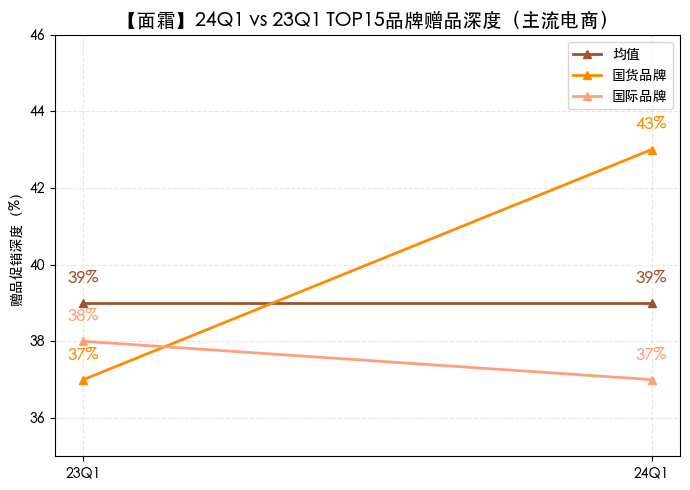

In [56]:
import matplotlib.pyplot as plt

# 数据
quarters = ['23Q1', '24Q1']
categories = ['均值', '国货品牌', '国际品牌']
data = {
    '均值': [39, 39],
    '国货品牌': [37, 43],
    '国际品牌': [38, 37]
}
colors = ['#A0522D', '#FF8C00', '#FFA07A']  # 使用类似原图的配色

# 绘图
fig, ax = plt.subplots(figsize=(7, 5))
for idx, cat in enumerate(categories):
    ax.plot(quarters, data[cat], marker='^', label=cat, color=colors[idx], linewidth=2)

# 添加文本标签
for idx, cat in enumerate(categories):
    for i, quarter in enumerate(quarters):
        ax.text(quarter, data[cat][i] + 0.5, f"{data[cat][i]}%", color=colors[idx], ha='center', fontsize=12)



# 样式设置
ax.set_ylim(35, 46)
ax.set_title("【面霜】24Q1 vs 23Q1 TOP15品牌赠品深度（主流电商）", fontsize=14, weight='bold')
ax.legend(loc='best')
ax.set_ylabel("赠品促销深度（%）")
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
